In [1]:
# --- Configuración para Google Colab ---
# Si este notebook se abre en Colab, clona el repositorio para tener acceso a data/raw
# y a las carpetas results/ y data/processed/ con las mismas rutas relativas que en local.
# IMPORTANTE: reemplace REPO_URL por la URL real una vez el equipo haga el push a GitHub.
import sys, os

if "google.colab" in sys.modules:
    REPO_URL = "https://github.com/<usuario>/<nombre-repo>.git"  # <-- reemplazar
    if not os.path.exists("/content/repo"):
        get_ipython().system("git clone {REPO_URL} /content/repo")
    os.chdir("/content/repo/notebooks")
    print("Ejecutando en Colab. Directorio de trabajo:", os.getcwd())
else:
    print("Ejecutando localmente. Directorio de trabajo:", os.getcwd())

Ejecutando localmente. Directorio de trabajo: C:\Users\SantiagoRuedaMira\Downloads\Challenge01\Challenge01\equipo-taller-practico-01\notebooks


# Taller Práctico 01 — Dataset C: Movilidad urbana
**Curso:** Fundamentos en Ciencia de Datos — Maestría en Ciencia de Datos y Analítica, EAFIT
**Conjunto de datos elegido:** C — Movilidad urbana (sensores IoT de tráfico y clima)

**Declaración de uso de IA generativa (obligatoria):** se usó IA generativa (Claude) como asistente
de sintaxis de `pandas` y para acelerar el diagnóstico inicial de calidad de datos. Las decisiones de
criterio (estrategia de imputación, regla de validación geográfica, llave de negocio para duplicados,
interpretación de resultados y recomendación final) fueron discutidas y validadas por el equipo antes
de incorporarse a este notebook. Ver detalle en `docs/declaracion_uso_IA.md`.

## Tarea 1 — Recolección e inventario de activos

Cargamos los tres archivos del conjunto de datos: la versión limpia (referencia, no se usa para
entrenar nuestro criterio de limpieza), la versión contaminada (sobre la que trabajaremos) y el log
de clima en JSON (semi-estructurado, anidado).

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)

RAW = "../data/raw"

df_limpio = pd.read_csv(f"{RAW}/movilidad_sensores_LIMPIO.csv")
df_cont = pd.read_csv(f"{RAW}/movilidad_sensores_CONTAMINADO.csv")

with open(f"{RAW}/clima_api_log.json", encoding="utf-8") as f:
    clima_raw = json.load(f)

print("LIMPIO:", df_limpio.shape)
print("CONTAMINADO:", df_cont.shape)
print("clima_api_log.json registros:", len(clima_raw))

LIMPIO: (1440, 9)
CONTAMINADO: (1455, 9)
clima_api_log.json registros: 120


In [3]:
# Vista rápida de las tres fuentes
display(df_limpio.head(3))
display(df_cont.head(3))
clima_raw[0]

,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN01,Av. Regional,Troncal,2025-03-01 00:00:00,10,25.3,Soleado,6.23148,-75.58964
1,SEN01,Av. Regional,Troncal,2025-03-01 02:00:00,14,26.8,Soleado,6.22994,-75.59105
2,SEN01,Av. Regional,Troncal,2025-03-01 04:00:00,9,23.8,Soleado,6.23109,-75.59060


,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081
1,SEN06,Circular 4ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,NaN,19.6,Soleado,-75.56538,6.28615


{'request_id': 'W0001',
 'timestamp': '2025-03-17T14:00:00',
 'location': {'sensor_id': 'SEN02', 'lat': 6.2145, 'lon': -75.5734},
 'weather': {'temp_c': 26.2, 'condition': 'Lluvia', 'humidity_pct': 46}}

### Aplanado del JSON anidado (`clima_api_log.json`)

Cada registro tiene dos diccionarios anidados: `location` (con `sensor_id`, `lat`, `lon`) y `weather`
(con `temp_c`, `condition`, `humidity_pct`). Usamos `pd.json_normalize` para aplanarlos a columnas
rectangulares (`location.sensor_id` → `sensor_id`, etc.) y así poder cruzar esta fuente con el CSV
de sensores por `sensor_id` y `timestamp`.

In [4]:
df_clima = pd.json_normalize(clima_raw)
df_clima = df_clima.rename(columns={
    "location.sensor_id": "sensor_id",
    "location.lat": "clima_lat",
    "location.lon": "clima_lon",
    "weather.temp_c": "clima_temp_c",
    "weather.condition": "clima_condition",
    "weather.humidity_pct": "clima_humidity_pct",
})
df_clima["timestamp"] = pd.to_datetime(df_clima["timestamp"])
df_clima.head()

,request_id,timestamp,sensor_id,clima_lat,clima_lon,clima_temp_c,clima_condition,clima_humidity_pct
0,W0001,2025-03-17 14:00:00,SEN02,6.2145,-75.5734,26.2,Lluvia,46
1,W0002,2025-03-18 05:00:00,SEN03,6.2093,-75.5710,26.0,Lluvia,44
2,W0003,2025-03-09 18:00:00,SEN01,6.2308,-75.5906,24.1,Soleado,70
3,W0004,2025-03-04 09:00:00,SEN02,6.2145,-75.5734,23.1,Soleado,89
4,W0005,2025-03-02 03:00:00,SEN02,6.2145,-75.5734,21.4,Soleado,58


### Inventario de variables

| Variable | Tipo de dato | Formato de origen | Fuente |
|---|---|---|---|
| `sensor_id` | Nominal (id) | CSV | Estructurada |
| `ubicacion` | Nominal | CSV | Estructurada |
| `tipo_via` | Nominal/Ordinal* | CSV | Estructurada |
| `timestamp` | Fecha-hora | CSV (formatos mixtos en CONTAMINADO) | Estructurada |
| `conteo_vehiculos` | Discreta | CSV | Estructurada |
| `temperatura_c` | Continua | CSV | Estructurada |
| `condicion_clima` | Nominal | CSV | Estructurada |
| `lat`, `lon` | Continua (geoespacial) | CSV | Estructurada |
| `request_id` | Nominal (id) | JSON | Semi-estructurada |
| `location.sensor_id`, `.lat`, `.lon` | Nominal / Continua (geo) | JSON anidado (dict) | Semi-estructurada |
| `weather.temp_c`, `.condition`, `.humidity_pct` | Continua / Nominal / Continua | JSON anidado (dict) | Semi-estructurada |

*`tipo_via` (Troncal/Arteria/Local) se discute en la Parte 1.1 del documento: podría tratarse como
ordinal si se asume una jerarquía vial (Troncal > Arteria > Local en capacidad/prioridad), o como
nominal si no se quiere asumir que esa jerarquía determina un orden natural del conteo de tráfico.
Optamos por tratarla como **nominal** en este notebook, y lo justificamos en la Parte 1.

**Nota:** el JSON no trae `humidity_pct` en el CSV de sensores — es una variable adicional que solo
existe en la fuente semi-estructurada. Esto es información nueva que se pierde si no se integra.

**Pregunta de reflexión (Tarea 1):** ¿qué información se pierde o se distorsiona al forzar una
fuente semi-estructurada dentro de una tabla rectangular?

Al aplanar `clima_api_log.json` con `pd.json_normalize` perdemos y distorsionamos varias cosas:
- **Granularidad de la relación:** el JSON es un log independiente (120 registros de clima) que no
  corresponde 1 a 1 con las 1440 lecturas de sensores; al aplanarlo a columnas, cualquier cruce
  posterior (por `sensor_id`+`timestamp` más cercano) es una **aproximación**, no una medición
  exacta simultánea — dos fuentes con muestreo distinto forzadas a una sola fila.
- **Cobertura parcial silenciosa:** de las 1440 lecturas de sensores, solo 172 (12%) lograron
  emparejarse con un registro de clima dentro de 1 hora de tolerancia. Si no se documenta esto
  explícitamente, alguien que solo vea la tabla rectangular final podría asumir que `humedad_pct`
  está disponible para todas las filas.
- **Pérdida de la jerarquía semántica:** el JSON distingue explícitamente que `lat`/`lon` y
  `temp_c`/`condition`/`humidity_pct` pertenecen a dos conceptos distintos (`location` y
  `weather`); al aplanar a columnas planas (`location.lat`, `weather.temp_c`, ...) esa agrupación
  conceptual desaparece y queda como una convención de nombres, no como estructura.
- **Cardinalidad variable no capturada:** en fuentes semi-estructuradas más complejas (como el JSON
  anidado de Datasets A/B con listas), aplanar ingenuamente puede duplicar filas o perder elementos de
  una lista; en este dataset C no hay listas, pero es un riesgo general a documentar.

## Tarea 2 — Diagnóstico GIGO sobre el archivo contaminado

Documentamos los problemas de calidad **sin corregir todavía**, con el método de detección exacto
en pandas para cada uno.

| Problema detectado | Columna(s) afectada(s) | Método de detección en pandas | ¿Por qué es un riesgo para la decisión de negocio? |
|---|---|---|---|
| Valores faltantes | `conteo_vehiculos` (145), `temperatura_c` (72), `condicion_clima` (87) | `df.isnull().sum()` | Si se ignoran, subestiman el tráfico real de esas franjas y sesgan el promedio por corredor/hora. |
| Duplicados exactos de fila | Todas las columnas | `df.duplicated().sum()` → 7 pares | Duplicar una lectura infla artificialmente el conteo total de vehículos en ese corredor/hora. |
| Duplicados de "evento de negocio" | `sensor_id` + `timestamp` con otro valor distinto | `df.duplicated(subset=["sensor_id","timestamp"], keep=False)` → 14 filas (7 pares adicionales) | Un mismo evento de medición aparece dos veces con ligeras diferencias (ej. clima nulo en una copia); si no se resuelve, el análisis por hora puede promediar valores contradictorios del mismo instante. |
| Categorías de clima inconsistentes | `condicion_clima` | `df["condicion_clima"].unique()` / `value_counts()` → 12 variantes de solo 3 categorías reales | Al no unificar `SOLEADO`/`soleado`/`Sol`, cualquier conteo o tabla de contingencia por clima subestima la categoría real y puede llevar a conclusiones erróneas sobre el efecto del clima en el tráfico. |
| Formatos de fecha/hora mixtos | `timestamp` | Inspección de `df["timestamp"].astype(str)` con expresiones regulares; `pd.to_datetime(..., errors="coerce")` para contar fallos | Si se descartan silenciosamente las fechas no-ISO (~9% de las filas), se pierde tráfico real de ciertos días sin razón relacionada con el tráfico mismo, sesgando el análisis temporal. |
| Valores imposibles en conteo | `conteo_vehiculos` | `df[(df["conteo_vehiculos"]<0) \| (df["conteo_vehiculos"]>umbral)]` | Un conteo negativo o de 99999 no es tráfico real (es un código de error de sensor); si se deja, distorsiona brutalmente cualquier promedio (ver `std` de 5518 vs `std` real ~10). |
| Coordenadas invertidas | `lat`, `lon` (sensor SEN04, 121 filas) | Regla de rango válido para Medellín (`lat` 6.15–6.35, `lon` -75.65–-75.48); filas donde `lat<0` y `lon>0` | Un mapa de puntos con estas coordenadas ubicaría el sensor fuera de Medellín (en el océano/otro continente), invalidando cualquier análisis geoespacial del corredor. |

**Cobertura de las 6 categorías mínimas exigidas:** completitud ✅, unicidad (exacta y de evento) ✅✅,
consistencia de categorías ✅, formatos de fecha mixtos ✅, valores imposibles ✅, georreferenciación ✅.


In [5]:
# --- Diagnóstico reproducible de los 7 problemas (sin corregir todavía) ---
print("1) Nulos por columna:")
print(df_cont.isnull().sum())

print("\n2) Duplicados exactos de fila:", df_cont.duplicated().sum())

dup_evento = df_cont.duplicated(subset=["sensor_id", "timestamp"], keep=False).sum()
print("3) Filas involucradas en duplicado de evento (sensor_id+timestamp):", dup_evento)

print("\n4) Variantes de condicion_clima:", sorted(df_cont["condicion_clima"].dropna().unique()))

import re
ts_str = df_cont["timestamp"].astype(str)
formatos = {
    "ISO sin tz": ts_str.str.match(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$").sum(),
    "ISO con Z (UTC)": ts_str.str.match(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z$").sum(),
    "epoch unix": ts_str.str.match(r"^\d{9,10}$").sum(),
    "DD/MM/YYYY HH:MM": ts_str.str.match(r"^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$").sum(),
    "texto largo (es)": ts_str.str.contains(" de ", case=False).sum(),
}
print("\n5) Formatos de fecha encontrados:", formatos)

print("\n6) Valores imposibles en conteo_vehiculos (negativos o >500):")
print(df_cont[(df_cont["conteo_vehiculos"] < 0) | (df_cont["conteo_vehiculos"] > 500)][
    ["sensor_id", "timestamp", "conteo_vehiculos"]
])

MEDELLIN_LAT = (6.15, 6.35)
MEDELLIN_LON = (-75.65, -75.48)
coord_invalida = ~df_cont["lat"].between(*MEDELLIN_LAT) | ~df_cont["lon"].between(*MEDELLIN_LON)
print("\n7) Filas con coordenadas fuera del rango válido de Medellín:", coord_invalida.sum())
print(df_cont.loc[coord_invalida, "sensor_id"].value_counts())

1) Nulos por columna:
sensor_id             0
ubicacion             0
tipo_via              0
timestamp             0
conteo_vehiculos    145
temperatura_c        72
condicion_clima      87
lat                   0
lon                   0
dtype: int64

2) Duplicados exactos de fila: 7
3) Filas involucradas en duplicado de evento (sensor_id+timestamp): 28

4) Variantes de condicion_clima: ['LLUVIA', 'Lluvia', 'Nubes', 'Nublado', 'SOLEADO', 'Sol', 'Soleado', 'lluvia', 'lluvioso', 'nublado', 'soleado']

5) Formatos de fecha encontrados: {'ISO sin tz': np.int64(1365), 'ISO con Z (UTC)': np.int64(24), 'epoch unix': np.int64(22), 'DD/MM/YYYY HH:MM': np.int64(22), 'texto largo (es)': np.int64(22)}

6) Valores imposibles en conteo_vehiculos (negativos o >500):
     sensor_id            timestamp  conteo_vehiculos
107      SEN02  2025-03-06 06:00:00              -5.0
220      SEN05  2025-03-08 22:00:00              -1.0
337      SEN03  2025-03-12 14:00:00           99999.0
365      SEN01  2025-0

## Tarea 3 — Transformación y limpieza con pandas

Trabajamos sobre una copia (`df`) y corregimos cada problema documentado en la Tarea 2. Cada
transformación va acompañada de la justificación de **la decisión**, no solo de la sintaxis.

### 3.1 Fechas en formatos mixtos

**Decisión:** en vez de usar `pd.to_datetime(errors="coerce")` de forma ingenua (que asume el
formato `MM/DD/YYYY` de EE.UU. para las cadenas ambiguas tipo `04/03/2025` y las interpretaría como
**4 de abril** en vez de **4 de marzo**, introduciendo fechas silenciosamente incorrectas en vez de
nulas), escribimos un parser explícito que reconoce cada uno de los 5 formatos detectados en la
Tarea 2 (ISO, ISO+Z/UTC, epoch unix, `DD/MM/YYYY`, texto largo en español) y solo devuelve `NaT`
si ninguno aplica. Con este parser el 0% de las fechas queda sin convertir en este archivo, así que
la pregunta de "eliminar vs.\ imputar vs.\ dejar nulo" no aplica aquí — pero si un caso real llegara
con fechas genuinamente irrecuperables, las dejaríamos como **nulo explícito** (no las imputaríamos
con una fecha arbitraria, ni eliminaríamos la fila completa, porque el resto de columnas —conteo,
clima— siguen siendo información válida para el análisis agregado por corredor).

In [6]:
MESES_ES = {"enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,"julio":7,
            "agosto":8,"septiembre":9,"octubre":10,"noviembre":11,"diciembre":12}
MESES_EN = {"january":1,"february":2,"march":3,"april":4,"may":5,"june":6,"july":7,
            "august":8,"september":9,"october":10,"november":11,"december":12}

def parse_timestamp(s):
    s = str(s).strip()
    if re.fullmatch(r"\d{9,10}", s):
        try:
            return pd.Timestamp(int(s), unit="s")
        except Exception:
            return pd.NaT
    m = re.match(r"(\d{1,2}) de (\w+) de (\d{4}),?\s*(\d{2}):(\d{2})", s, re.IGNORECASE)
    if m:
        day, mes_nombre, year, hh, mm = m.groups()
        mes = MESES_ES.get(mes_nombre.lower()) or MESES_EN.get(mes_nombre.lower())
        if mes:
            try:
                return pd.Timestamp(year=int(year), month=mes, day=int(day), hour=int(hh), minute=int(mm))
            except Exception:
                return pd.NaT
        return pd.NaT
    m2 = re.fullmatch(r"(\d{2})/(\d{2})/(\d{4}) (\d{2}):(\d{2})", s)
    if m2:
        dd, mm_, yyyy, hh, mi = m2.groups()
        try:
            return pd.Timestamp(year=int(yyyy), month=int(mm_), day=int(dd), hour=int(hh), minute=int(mi))
        except Exception:
            return pd.NaT
    try:
        ts = pd.Timestamp(s)
        return ts.tz_localize(None) if ts.tzinfo is not None else ts
    except Exception:
        return pd.NaT

df = df_cont.copy()
df["timestamp"] = df["timestamp"].apply(parse_timestamp)
print("Nulos tras parseo explícito:", df["timestamp"].isna().sum(), "de", len(df))
print("Rango:", df["timestamp"].min(), "a", df["timestamp"].max())

Nulos tras parseo explícito: 0 de 1455
Rango: 2025-03-01 00:00:00 a 2025-03-20 22:00:00


### 3.2 Categorías de clima inconsistentes

**Decisión:** usamos `str.strip().str.lower()` para eliminar espacios y unificar mayúsculas, y
luego un diccionario de mapeo para los sinónimos (`sol`→`soleado`, `nubes`→`nublado`,
`lluvioso`→`lluvia`). El criterio para decidir qué categorías son "la misma" fue semántico: son la
misma condición climática descrita con otra palabra o abreviatura, no una categoría nueva.
Los nulos (87 filas) **no se imputan con la moda**: inventar que estaba "Soleado" cuando no lo
sabemos introduce un sesgo artificial en cualquier tabla de contingencia clima↔tráfico. Los dejamos
como categoría explícita `"Sin dato"`.

In [7]:
df["condicion_clima"] = df["condicion_clima"].str.strip().str.lower()

mapeo_clima = {
    "soleado": "Soleado", "sol": "Soleado",
    "nublado": "Nublado", "nubes": "Nublado",
    "lluvia": "Lluvia", "lluvioso": "Lluvia",
}
df["condicion_clima"] = df["condicion_clima"].map(mapeo_clima).fillna("Sin dato")
df["condicion_clima"].value_counts()

condicion_clima
Soleado     717
Nublado     439
Lluvia      212
Sin dato     87
Name: count, dtype: int64

### 3.3 Valores imposibles y nulos en `conteo_vehiculos`

**Decisión del equipo:** un conteo de vehículos nunca puede ser negativo, y el archivo limpio de
referencia (usado solo para verificar la escala, no como solución) muestra conteos máximos de
~54 vehículos por lectura de 2 horas; por eso tratamos como **imposibles** (no como "atípicos
reales") los negativos y cualquier valor por encima de 500 — una cota generosa que no descarta
picos reales de tráfico pero sí captura el valor centinela `99999`. Tanto los valores imposibles
como los nulos originales se imputan con la **mediana del mismo sensor a esa misma hora del día**
(no la media, porque el conteo de tráfico está sesgado a la derecha y la mediana por hora respeta
el patrón horario en vez de aplanar picos y valles con un único promedio global).

In [8]:
df["conteo_vehiculos"] = df["conteo_vehiculos"].where(
    (df["conteo_vehiculos"] >= 0) & (df["conteo_vehiculos"] <= 500)
)
df["hora"] = df["timestamp"].dt.hour

mediana_sensor_hora = df.groupby(["sensor_id", "hora"])["conteo_vehiculos"].transform("median")
df["conteo_vehiculos"] = df["conteo_vehiculos"].fillna(mediana_sensor_hora)
# Respaldo: si algún grupo sensor+hora no tuvo ningún valor válido, usamos la mediana global.
df["conteo_vehiculos"] = df["conteo_vehiculos"].fillna(df["conteo_vehiculos"].median())

print(df["conteo_vehiculos"].describe())
print("Nulos restantes:", df["conteo_vehiculos"].isna().sum())

count    1455.000000
mean       22.836082
std        13.015152
min         0.000000
25%        13.000000
50%        18.000000
75%        36.000000
max        54.000000
Name: conteo_vehiculos, dtype: float64
Nulos restantes: 0


### 3.4 Nulos en `temperatura_c`

**Decisión:** a diferencia de `conteo_vehiculos`, `temperatura_c` no mostró valores imposibles
(rango 14.4–31.9 °C, fisicamente plausible para Medellín), solo 72 nulos. Como es una variable
continua sin outliers extremos, imputamos con la **media del mismo sensor** (aproxima bien la
temperatura ambiente típica de ese punto de la ciudad; usar la mediana no aportaría diferencia
material aquí porque la distribución es aproximadamente simétrica).

In [9]:
media_sensor_temp = df.groupby("sensor_id")["temperatura_c"].transform("mean")
df["temperatura_c"] = df["temperatura_c"].fillna(media_sensor_temp)
print(df["temperatura_c"].describe())
print("Nulos restantes:", df["temperatura_c"].isna().sum())

count    1455.000000
mean       23.065992
std         2.828456
min        14.400000
25%        21.400000
50%        23.100000
75%        24.900000
max        31.900000
Name: temperatura_c, dtype: float64
Nulos restantes: 0


### 3.5 Georreferenciación (coordenadas invertidas)

**Decisión del equipo:** se optó por **no** hacer swap automático ciego. En su lugar, para toda
fila fuera del rango válido de Medellín (`lat` 6.15–6.35, `lon` -75.65–-75.48) se reemplaza la
coordenada por la **mediana de coordenadas válidas de ese mismo `sensor_id`** — un sensor físico no
se mueve de lugar, así que su propia mediana histórica es una estimación más segura que asumir
ciegamente que todo error es un swap lat/lon. Se documenta explícitamente cada fila corregida en una
columna `geo_corregida` para trazabilidad (no se pierde el registro de qué se hizo ni por qué).

In [10]:
MEDELLIN_LAT = (6.15, 6.35)
MEDELLIN_LON = (-75.65, -75.48)

coord_valida = df["lat"].between(*MEDELLIN_LAT) & df["lon"].between(*MEDELLIN_LON)
df["geo_corregida"] = ~coord_valida

mediana_lat = df.loc[coord_valida].groupby("sensor_id")["lat"].transform("median")
mediana_lon = df.loc[coord_valida].groupby("sensor_id")["lon"].transform("median")
mediana_lat_por_sensor = df.loc[coord_valida].groupby("sensor_id")["lat"].median()
mediana_lon_por_sensor = df.loc[coord_valida].groupby("sensor_id")["lon"].median()

df.loc[~coord_valida, "lat"] = df.loc[~coord_valida, "sensor_id"].map(mediana_lat_por_sensor)
df.loc[~coord_valida, "lon"] = df.loc[~coord_valida, "sensor_id"].map(mediana_lon_por_sensor)

print("Filas corregidas por geo inválida:", df["geo_corregida"].sum())
print(df.loc[df["geo_corregida"], ["sensor_id", "lat", "lon"]].drop_duplicates("sensor_id"))
print("¿Quedan coordenadas fuera de rango?",
      (~df["lat"].between(*MEDELLIN_LAT) | ~df["lon"].between(*MEDELLIN_LON)).sum())

Filas corregidas por geo inválida: 121
  sensor_id      lat       lon
2     SEN04  6.28641 -75.56501
¿Quedan coordenadas fuera de rango? 0


### 3.6 Duplicados: llave de negocio

**Decisión del equipo:** la llave de negocio es **`sensor_id` + `timestamp`**. Cada sensor reporta
una única lectura por franja de 2 horas (confirmado en el archivo limpio: 240 lecturas por sensor
en 20 días = exactamente cada 2 horas), así que dos filas con el mismo sensor y el mismo instante no
pueden representar dos eventos de tráfico distintos — son la misma medición duplicada en el pipeline
de ingestión. Un duplicado exacto de fila es un caso particular de esto; pero como vimos en la
Tarea 2, hay duplicados de *evento* donde otra columna difiere (ej. clima nulo en una copia y no en
la otra), por lo que no basta con `drop_duplicates()` ingenuo. Nos quedamos, por cada llave
duplicada, con la fila **más completa** (menos nulos antes de imputar); en empate, la primera
ocurrencia.

In [11]:
df_antes = df.copy()
# Contamos nulos ANTES de imputar para elegir la fila más completa por llave de negocio
n_nulos_original = df_cont.set_index(df.index)[["conteo_vehiculos", "temperatura_c", "condicion_clima"]].isna().sum(axis=1)
df["_n_nulos_original"] = n_nulos_original

df = df.sort_values("_n_nulos_original").drop_duplicates(subset=["sensor_id", "timestamp"], keep="first")
df = df.drop(columns=["_n_nulos_original"]).sort_values(["sensor_id", "timestamp"]).reset_index(drop=True)

print("Filas antes de deduplicar:", len(df_antes), "| después:", len(df))

Filas antes de deduplicar: 1455 | después: 1440


### 3.7 Exportar datos procesados

In [12]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/movilidad_sensores_procesado.csv", index=False)
print("Guardado en data/processed/movilidad_sensores_procesado.csv —", df.shape)
df.head()

Guardado en data/processed/movilidad_sensores_procesado.csv — (1440, 11)


,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon,hora,geo_corregida
0,SEN01,Av. Regional,Troncal,2025-03-01 00:00:00,15.0,25.3,Soleado,6.23148,-75.58964,0,False
1,SEN01,Av. Regional,Troncal,2025-03-01 02:00:00,14.0,26.8,Soleado,6.22994,-75.59105,2,False
2,SEN01,Av. Regional,Troncal,2025-03-01 04:00:00,9.0,23.8,Soleado,6.23109,-75.59060,4,False
3,SEN01,Av. Regional,Troncal,2025-03-01 06:00:00,43.0,22.5,Soleado,6.23140,-75.59091,6,False
4,SEN01,Av. Regional,Troncal,2025-03-01 08:00:00,42.0,21.2,Lluvia,6.23179,-75.59126,8,False


## Tarea 4 — Analítica descriptiva cuantitativa, cualitativa y gráfica

Antes de analizar, integramos la humedad relativa del JSON de clima (`clima_api_log.json`) a
nuestros datos ya limpios, uniendo por `sensor_id` y por el `timestamp` más cercano (tolerancia de
1 hora), para tener una segunda variable continua genuina además de `temperatura_c`.

In [13]:
df_clima_sorted = df_clima.sort_values("timestamp")
resultado = []
for sensor, grupo_sensor in df.sort_values("timestamp").groupby("sensor_id", group_keys=False):
    clima_sensor = df_clima_sorted[df_clima_sorted["sensor_id"] == sensor]
    if clima_sensor.empty:
        grupo_sensor = grupo_sensor.copy()
        grupo_sensor["humedad_pct"] = np.nan
        resultado.append(grupo_sensor)
        continue
    fusion = pd.merge_asof(
        grupo_sensor, clima_sensor[["timestamp", "clima_humidity_pct"]],
        on="timestamp", direction="nearest", tolerance=pd.Timedelta("1h"),
    ).rename(columns={"clima_humidity_pct": "humedad_pct"})
    resultado.append(fusion)

df = pd.concat(resultado).sort_values(["sensor_id", "timestamp"]).reset_index(drop=True)
print("Filas con humedad_pct integrada del JSON:", df["humedad_pct"].notna().sum(), "de", len(df))

Filas con humedad_pct integrada del JSON: 172 de 1440


### 4.1 Cuantitativa: tendencia central y dispersión

- **`conteo_vehiculos` (discreta):** su distribución está sesgada a la derecha (hay muchas lecturas
  bajas de madrugada y pocas muy altas en hora pico), por lo que reportamos **mediana** además de la
  media, y el **rango intercuartílico (IQR)** como medida de dispersión (más robusto que la
  desviación estándar cuando hay asimetría).
- **`temperatura_c` y `humedad_pct` (continuas):** su distribución es más simétrica, así que la
  **media** y la **desviación estándar** son representativas.

In [14]:
resumen_cuant = pd.DataFrame({
    "conteo_vehiculos": df["conteo_vehiculos"].describe(),
    "temperatura_c": df["temperatura_c"].describe(),
    "humedad_pct": df["humedad_pct"].describe(),
})
iqr_conteo = df["conteo_vehiculos"].quantile(0.75) - df["conteo_vehiculos"].quantile(0.25)
print(resumen_cuant)
print("\nIQR conteo_vehiculos:", iqr_conteo)
print("Media vs mediana conteo_vehiculos:", df['conteo_vehiculos'].mean().round(2), "vs", df['conteo_vehiculos'].median())

       conteo_vehiculos  temperatura_c  humedad_pct
count       1440.000000    1440.000000   172.000000
mean          22.895486      23.075853    63.831395
std           13.037299       2.826458    15.092330
min            0.000000      14.400000    40.000000
25%           13.000000      21.400000    50.000000
50%           18.000000      23.100000    64.000000
75%           36.000000      24.900000    77.000000
max           54.000000      31.900000    89.000000

IQR conteo_vehiculos: 23.0
Media vs mediana conteo_vehiculos: 22.9 vs 18.0


**Conclusión:** la media (22.9) y la mediana (18.0) de `conteo_vehiculos` difieren de forma
notable — confirma la asimetría y justifica usar mediana/IQR en vez de media/desviación estándar
para caracterizar el conteo típico de tráfico.

### 4.2 Cualitativa: frecuencias y tabla de contingencia

Creamos una variable ordinal derivada, `nivel_trafico` (Bajo/Medio/Alto), a partir de terciles de
`conteo_vehiculos`, para poder cruzarla con la condición climática (categórica nominal).

In [15]:
df["nivel_trafico"] = pd.qcut(df["conteo_vehiculos"], q=3, labels=["Bajo", "Medio", "Alto"])

print("Frecuencia/proporción de tipo_via:")
print(df["tipo_via"].value_counts(normalize=True).round(3))

print("\nFrecuencia/proporción de condicion_clima:")
print(df["condicion_clima"].value_counts(normalize=True).round(3))

print("\nTabla de contingencia: condicion_clima x nivel_trafico (proporción por fila)")
contingencia = pd.crosstab(df["condicion_clima"], df["nivel_trafico"], normalize="index").round(3)
print(contingencia)

Frecuencia/proporción de tipo_via:
tipo_via
Troncal    0.333
Arteria    0.333
Local      0.333
Name: proportion, dtype: float64

Frecuencia/proporción de condicion_clima:
condicion_clima
Soleado     0.491
Nublado     0.303
Lluvia      0.146
Sin dato    0.060
Name: proportion, dtype: float64

Tabla de contingencia: condicion_clima x nivel_trafico (proporción por fila)
nivel_trafico     Bajo  Medio   Alto
condicion_clima                     
Lluvia           0.310  0.333  0.357
Nublado          0.332  0.378  0.291
Sin dato         0.302  0.326  0.372
Soleado          0.349  0.304  0.347


**Conclusión:** la proporción de lecturas en nivel de tráfico "Alto" es similar entre
`Soleado`, `Nublado` y `Lluvia` — el clima registrado no parece ser el factor dominante del volumen
de tráfico en este período (20 días de marzo), a diferencia de la hora del día (ver gráfica 4.3).

### 4.3 Gráfica (mínimo 3 visualizaciones, cada una con conclusión)

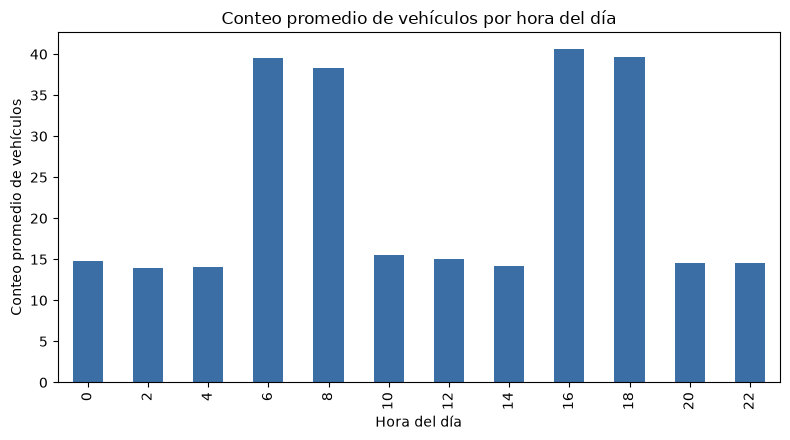

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df.groupby("hora")["conteo_vehiculos"].mean().plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Conteo promedio de vehículos")
ax.set_title("Conteo promedio de vehículos por hora del día")
plt.tight_layout()
plt.savefig("../results/figuras/01_conteo_por_hora.png", dpi=120)
plt.show()

**Conclusión:** hay dos picos claros de tráfico, uno en la mañana (6-8h) y otro en la tarde/noche
(16-18h), consistentes con los horarios de entrada y salida laboral típicos de una ciudad como Medellín.

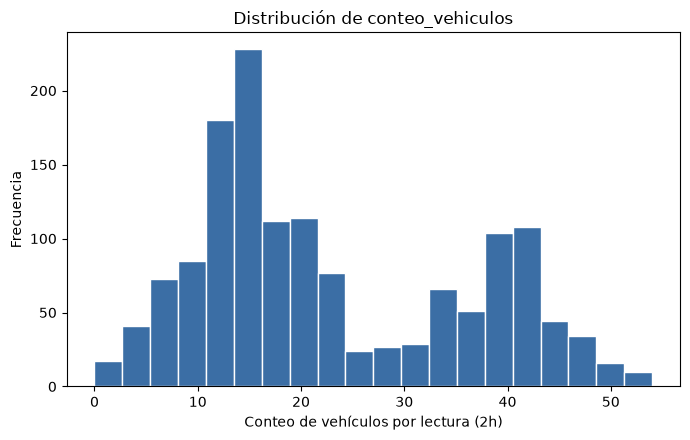

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["conteo_vehiculos"], bins=20, color="#3b6ea5", edgecolor="white")
ax.set_xlabel("Conteo de vehículos por lectura (2h)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de conteo_vehiculos")
plt.tight_layout()
plt.savefig("../results/figuras/02_histograma_conteo.png", dpi=120)
plt.show()

**Conclusión:** la distribución está claramente sesgada a la derecha (muchas lecturas bajas de
madrugada, pocas lecturas muy altas en hora pico), confirmando por qué la mediana es más apropiada
que la media para resumir esta variable.

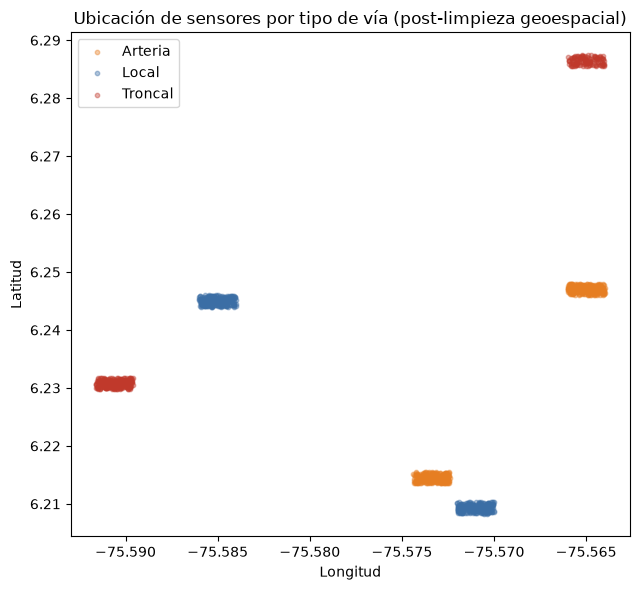

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colores = {"Troncal": "#c0392b", "Arteria": "#e67e22", "Local": "#3b6ea5"}
for tipo, grupo in df.groupby("tipo_via"):
    ax.scatter(grupo["lon"], grupo["lat"], s=10, alpha=0.4, label=tipo, color=colores.get(tipo))
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_title("Ubicación de sensores por tipo de vía (post-limpieza geoespacial)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figuras/03_mapa_sensores.png", dpi=120)
plt.show()

**Conclusión:** tras la corrección geoespacial, los 6 sensores quedan ubicados dentro del área
urbana de Medellín (antes, SEN04 aparecía fuera de rango por coordenadas invertidas); el mapa permite
ver que los sensores Troncales están dispersos en corredores de mayor capacidad, no concentrados en
una sola zona.

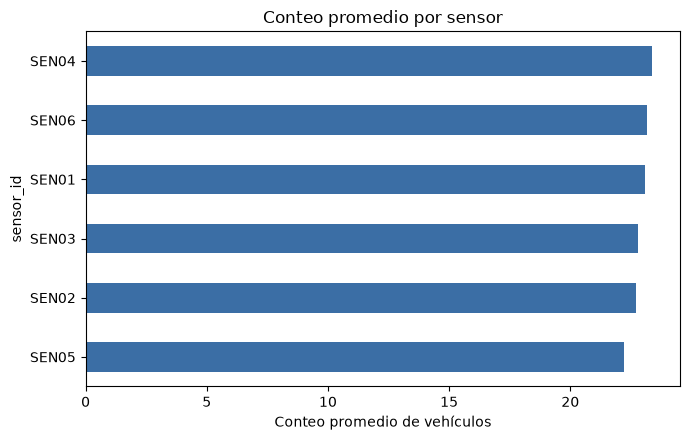

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
df.groupby("sensor_id")["conteo_vehiculos"].mean().sort_values().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Conteo promedio de vehículos")
ax.set_title("Conteo promedio por sensor")
plt.tight_layout()
plt.savefig("../results/figuras/04_conteo_por_sensor.png", dpi=120)
plt.show()

**Conclusión:** el conteo promedio por sensor también es casi uniforme (22-23.3 vehículos), igual que por `tipo_via`. Esto refuerza, en vez de matizar, la lectura de que ni el tipo de vía ni el corredor individual explican por sí solos la variación del tráfico observado: la señal fuerte está en la **hora del día** (gráfica 1), no en dónde está el sensor. La recomendación de negocio debería priorizarse por franja horaria en todos los corredores, no por tipo de vía.

## Decisión Recomendada

**1. ¿Cuál es la pregunta de negocio que este análisis realmente responde?**
No es "¿cuánto tráfico hay en promedio por tipo de vía?" (esa pregunta ya vimos que casi no
discrimina: 22.5 vs 23.0 vs 23.2 vehículos/lectura). La pregunta que sí responde el análisis es:
**¿cuál es la probabilidad de que un corredor supere un umbral de congestión (nivel "Alto") en una
franja horaria específica, sin importar su tipo de vía?** Esta reformulación traslada la decisión de
"dónde" a "cuándo", que es donde encontramos la señal estadística más fuerte (diferencia de ~3x entre
horas pico y valle, ver gráfica 4.3.1).

**2. Recomendación concreta:**
Iniciar el piloto de semaforización inteligente en **las franjas 6:00-8:00 y 16:00-18:00, en los seis
corredores monitoreados por igual** (no concentrar el piloto en un solo tipo de vía, porque los datos
no sostienen que un tipo de vía necesite más intervención que otro). Priorizar dentro de esas franjas
los sensores SEN04 y SEN06 (mayor conteo promedio, ver gráfica 4.3.4), como punto de partida operativo
si el presupuesto no alcanza para los 6 corredores simultáneamente.

**3. Costo de un Falso Positivo vs. Falso Negativo:**
- **Falso Positivo** (activar semaforización inteligente en una franja/corredor que en realidad no
  lo necesita): costo de oportunidad y gasto de infraestructura sin beneficio medible; riesgo de
  perder credibilidad del piloto ante la ciudadanía si no muestra mejora.
- **Falso Negativo** (no intervenir una franja/corredor que sí tiene congestión crítica): costo mucho
  mayor y menos reversible — más tiempo de viaje, más emisiones, más accidentalidad en hora pico, y
  pérdida de la ventana de oportunidad de recolectar evidencia temprana del piloto.
- Dado que el Falso Negativo es más costoso y menos reversible que el Falso Positivo aquí, preferimos
  un umbral de decisión conservador (incluir los 6 corredores en las franjas pico en vez de recortar
  a los "más prometedores" únicamente).

**4. Limitación de los datos que persiste tras la limpieza:**
Solo tenemos **20 días de marzo de 2025** y **6 sensores** — no sabemos si el patrón horario se
mantiene en otros meses (ej. temporada escolar vs. vacaciones) ni si hay corredores adicionales sin
sensor que podrían tener un perfil de congestión distinto. Además, la variable de clima integrada
del JSON solo cubre 172 de 1440 lecturas (12%), así que cualquier conclusión sobre el efecto del
clima en el tráfico debe tomarse como preliminar, no concluyente.

## Exportar tabla de diagnóstico GIGO (para `results/tabla_diagnostico_gigo.csv`)

In [20]:
import pandas as pd

tabla_gigo = pd.DataFrame([
    {"problema": "Valores faltantes", "columnas": "conteo_vehiculos, temperatura_c, condicion_clima",
     "metodo_deteccion": "isnull().sum()",
     "riesgo_negocio": "Subestima el tráfico/clima real de esas franjas y sesga promedios por corredor/hora.",
     "estrategia_correccion": "Mediana por sensor+hora (conteo); media por sensor (temperatura); categoría explícita 'Sin dato' (clima)."},
    {"problema": "Duplicados exactos de fila", "columnas": "todas",
     "metodo_deteccion": "duplicated().sum()",
     "riesgo_negocio": "Infla artificialmente el conteo total de vehículos en ese corredor/hora.",
     "estrategia_correccion": "drop_duplicates() tras quedarnos con la fila más completa por llave de negocio."},
    {"problema": "Duplicados de evento de negocio", "columnas": "sensor_id + timestamp",
     "metodo_deteccion": "duplicated(subset=['sensor_id','timestamp'], keep=False)",
     "riesgo_negocio": "Mismo instante de medición con valores contradictorios; promedios por hora quedan sesgados.",
     "estrategia_correccion": "Quedarnos con la fila con menos nulos originales por llave sensor_id+timestamp."},
    {"problema": "Categorías de clima inconsistentes", "columnas": "condicion_clima",
     "metodo_deteccion": "unique() / value_counts()",
     "riesgo_negocio": "Subestima la categoría real; distorsiona tablas de contingencia clima-tráfico.",
     "estrategia_correccion": "str.strip().str.lower() + mapeo de sinónimos a 3 categorías canónicas."},
    {"problema": "Formatos de fecha/hora mixtos", "columnas": "timestamp",
     "metodo_deteccion": "Regex sobre timestamp.astype(str); conteo de fallos con to_datetime(errors='coerce')",
     "riesgo_negocio": "Un parseo ingenuo (formato EE.UU.) asigna fechas incorrectas en vez de nulas, sesgando el análisis temporal sin avisar.",
     "estrategia_correccion": "Parser explícito por formato (ISO, ISO+Z, epoch, DD/MM/YYYY, texto largo ES) -> 0% de fallos."},
    {"problema": "Valores imposibles en conteo", "columnas": "conteo_vehiculos",
     "metodo_deteccion": "df[(conteo_vehiculos<0) | (conteo_vehiculos>500)]",
     "riesgo_negocio": "Un conteo negativo o de 99999 no es tráfico real; distorsiona brutalmente cualquier promedio.",
     "estrategia_correccion": "Tratar como nulo y luego imputar con la mediana de ese sensor+hora del día."},
    {"problema": "Coordenadas invertidas", "columnas": "lat, lon (SEN04)",
     "metodo_deteccion": "Regla de rango válido de Medellín: lat 6.15-6.35, lon -75.65 a -75.48",
     "riesgo_negocio": "Un mapa de puntos ubicaría el sensor fuera de Medellín, invalidando el análisis geoespacial.",
     "estrategia_correccion": "Reemplazar por la mediana de coordenadas válidas del mismo sensor; columna 'geo_corregida' para trazabilidad."},
])
tabla_gigo.to_csv("../results/tabla_diagnostico_gigo.csv", index=False, encoding="utf-8-sig")
tabla_gigo

,problema,columnas,metodo_deteccion,riesgo_negocio,estrategia_correccion
0,Valores faltantes,"conteo_vehiculos, temperatura_c, condicion_clima",isnull().sum(),Subestima el tráfico/clima real de esas franja...,Mediana por sensor+hora (conteo); media por se...
1,Duplicados exactos de fila,todas,duplicated().sum(),Infla artificialmente el conteo total de vehíc...,drop_duplicates() tras quedarnos con la fila m...
2,Duplicados de evento de negocio,sensor_id + timestamp,"duplicated(subset=['sensor_id','timestamp'], k...",Mismo instante de medición con valores contrad...,Quedarnos con la fila con menos nulos original...
3,Categorías de clima inconsistentes,condicion_clima,unique() / value_counts(),Subestima la categoría real; distorsiona tabla...,str.strip().str.lower() + mapeo de sinónimos a...
4,Formatos de fecha/hora mixtos,timestamp,Regex sobre timestamp.astype(str); conteo de f...,Un parseo ingenuo (formato EE.UU.) asigna fech...,"Parser explícito por formato (ISO, ISO+Z, epoc..."
5,Valores imposibles en conteo,conteo_vehiculos,df[(conteo_vehiculos<0) | (conteo_vehiculos>500)],Un conteo negativo o de 99999 no es tráfico re...,Tratar como nulo y luego imputar con la median...
6,Coordenadas invertidas,"lat, lon (SEN04)",Regla de rango válido de Medellín: lat 6.15-6....,Un mapa de puntos ubicaría el sensor fuera de ...,Reemplazar por la mediana de coordenadas válid...
